In [2]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

# Mode in reflection

Here we use a non-RWA model of a driven linear mode.

We can sweep a variety of mode parameters and drive parameters.

In particular, we adjust $\kappa_{int}$, $\kappa_{ext}$, and the Kerr nonlinearity $K$. We sweep the drive frequency and power. For a finite Kerr, we see an increasingly nonlinear response for larger drive powers.

In [114]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(50e6*2*pi)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
sim.add_param('K', -10e6 * 2 * np.pi)
sim.add_param('gr', 1e6 * 2 * np.pi)
sim.add_paramsweep('amplR',  0, 60000, 101)
sim.add_param('wa', 5.00e9*2*pi, is_excitation=True)
# sim.add_paramsweep('wa', 4.99e9*2*pi, 5.01e9*2*pi, 101)  #this simulates a slow dephasing effect
sim.add_paramsweep('wR', 4.85e9 * 2 * np.pi, 5.15e9 * 2 * np.pi, 101)
sim.add_param('rampR', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 50e-9)
sim.add_param('phaseR', 0)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*K*abs(a)**2 ')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=40, num_cycles=500, d_factor=1)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


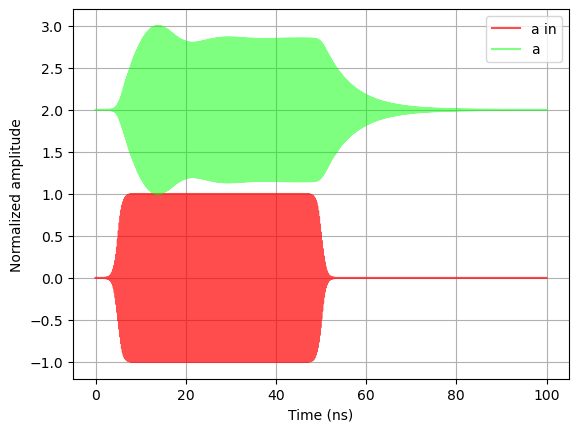

In [115]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [116]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [00:10<00:00, 1908.00it/s]


 
...finished GPU solve!


In [117]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[2,:]+1j*Qd[2,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

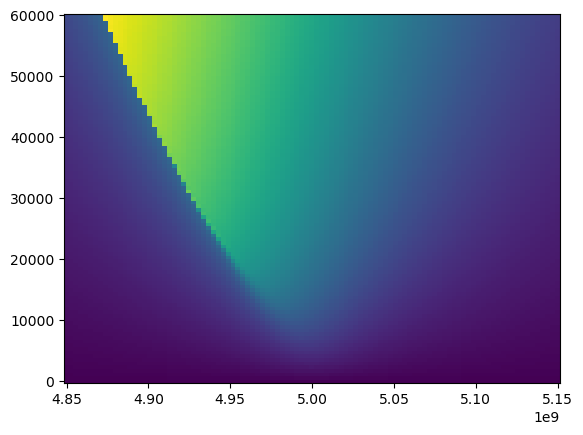

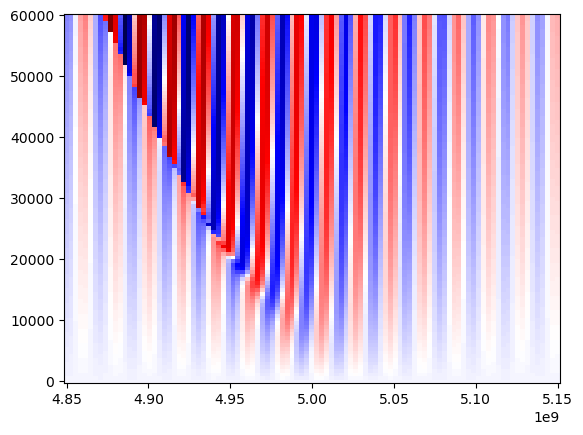

In [118]:
S11 = np.mean(aout[:,:,300:], axis=2)

amplR = sim.paramsweep_dict['amplR']
wR = sim.paramsweep_dict['wR']/(2*np.pi)

plt.pcolor(wR, amplR, np.abs(S11))
plt.show()
plt.pcolor(wR, amplR, np.real(S11), cmap='seismic')
plt.show()